## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm
from CIBUSmod.utils.output_data_manip import concat_herds, get_GHG
import CIBUSmod.utils.plot as plot

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Set up scenario and modules

Set path to folders containing all default and scenario data. Select the 'baseline' scenario, define years to calculate output for and create a container to store outputs per year. To save time we use 10-year time steps, but 1-year time steps are also possible.

In [15]:
# Set paths to default and scenario data
cm.ParameterRetriever.set_data_folders(
    default = os.path.join('..','data','prod_parameters'),
    scenarios = os.path.join('..','data','scenarios'),
    relation_tables = os.path.join('..','data','relation_tables.xlsx')
)

# Define scenario, years and create output container
scn = 'base year'
year = '2020'
output = cm.Output()

## Instantiate modules and run model

In [4]:
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions')
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    index = regions.x0_crops.index
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt')
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    par = cm.ParameterRetriever('ManureMgmt')
)

# Instantiate plant nutrient management
plant_nutrient_mgmt = cm.PlantNutrientMgmt(
    demand = demand,
    regions = regions,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('PlantNutrientMgmt')
)

# Instatiate machinery and energy management
machinery_and_energy_mgmt  = cm.MachineryAndEnergyMgmt(
    regions = regions,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('MachineryAndEnergyMgmt')
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('GeoDistributor')
)

In [72]:
# Reload parameter data
cm.ParameterRetriever.update_all_parameter_values()

# Get region attributes
regions.calculate(verbose=True)

# Calculate food demand
demand.calculate(verbose=True)

# Calculate crops
crops.calculate(
    verbose = True
)

# Calculate herds
for h in herds:
    h.calculate(verbose = True)

# Calculate feed
feed_mgmt.calculate(verbose=True)

# Distribute animals and crops
# Make optimisation problem
geodist.make(use_cons=[1,2,3,4,5,6,7], scale_power=0.4, verbose=True)
# Solve optimisation problem
geodist.solve(
    verbose=True,
    solver_settings = {
        'solver':'OSQP',
        'max_iter':200000,
        'eps_abs':5e-6,
        'eps_rel':5e-6,
        'verbose':False
    }
)

# Redistribute feeds (not yet implemented) and calculate enteric CH4 emissions
feed_mgmt.calculate2(verbose=True)

# Calculate manure
manure_mgmt.calculate(verbose=True)

# Calculate plant nutrient management
plant_nutrient_mgmt.calculate(verbose=True)

# Calculate energy requirements
machinery_and_energy_mgmt.calculate(verbose=True)

# Store results
output.store(
    scn, year,
    demand, regions, crops, herds
)

[22:11:28][Regions] Getting initial crop areas and animal numbers (x0) ...
[22:11:28][Regions] Getting climate and soil attributes ...
[22:11:28][Regions] Calculating maximum land use ...
[22:11:28][Regions] Done! Elapsed time: 0 sec
[22:11:28][DemandAndConversions] Calculating food demand ...
[22:11:28][DemandAndConversions] Calculating waste ...
[22:11:28][DemandAndConversions] Calculating crop product demand ...
[22:11:29][DemandAndConversions] Calculating animal product demand ...
[22:11:29][DemandAndConversions] Done! Elapsed time: 1 sec
[22:11:29][CropProduction] Calculating harvest ...
[22:11:29][CropProduction] Calculating production ...
[22:11:31][CropProduction] Calculating crop residues ...
[22:11:31][CropProduction] Calculating seed demand ...
[22:11:32][CropProduction] Done! Elapsed time: 3 sec
[22:11:32][AnimalHerd (cattle, beef, conventional, maize based)] Calculating herd structure ...
[22:11:32][AnimalHerd (cattle, beef, conventional, maize based)] Calculating producti

[22:11:46][AnimalHerd (poultry, layer, organic, none)] Calculating production ...
[22:11:46][AnimalHerd (poultry, layer, organic, none)] Calculating feed energy or DM requirements ...
[22:11:46][AnimalHerd (poultry, layer, organic, none)] Done! Elapsed time: 0 sec
[22:11:46][FeedMgmt] Calculating feed consumption ...
[22:11:49][FeedMgmt] Calculating feed losses ...
[22:11:54][FeedMgmt] Calculating demand for crop products ...
[22:12:03][FeedMgmt] Calculating demand for by-products ...
[22:12:10][FeedMgmt] Done! Elapsed time: 24 sec
[22:12:10][GeoDistributor.make] Getting x0 and making indexes ...
[22:12:10][GeoDistributor.make] Creating demand vector ...
[22:12:10][GeoDistributor.make] Scaling ...
[22:12:10][GeoDistributor.make] Making objective O1 ...
[22:12:11][GeoDistributor.make] Making constraint C1 ...
[22:12:27][GeoDistributor.make] Making constraint C2 ...
[22:12:29][GeoDistributor.make] Making constraint C3 ...
[22:12:29][GeoDistributor.make] Making constraint C4 ...
[22:12:29

## Store results

In [12]:
# Write file
output.save_file('out_base_year.bz2')

In [19]:
# Read file
output = cm.Output.from_file('out_base_year.bz2')

In [20]:
output.info()

*-----------------*
| CIBUSmod Output |
*-----------------*

Scenarios
---------
base year: 2020 

DemandAndConversions
--------------------
Data attributes:
animal_prod_demand, non_food_demand, export_demand, food_demand, crop_by_products, waste, animal_by_products, food_demand_to_processing, crop_prod_demand, population


Regions
-------
Data attributes:
soil, climate, x0_animals, x0_crops, max_land_use


CropProduction
--------------
Data attributes:
fertiliser.mineral_N, fertiliser.manure_N_soil_loss, production_per_use, fertiliser.manure_C, fertiliser.mineral_N_application_loss, production, fertiliser.organic_soil_N_loss, fertiliser.mineral_N_soil_loss, harvest, fertiliser.crop_residues_N, harvest_dm, crop_residues, seed_demand, fertiliser.TAN_req, fertiliser.crop_residues_N_soil_loss, fertiliser.manure_N_application_loss, energy_use_emissions, fertiliser.manure_N, fertiliser.manure_TAN, energy_use, area, harvested_crop_residues


AnimalHerd
----------
Data attributes:
lwg, feed.d

# Check solution

In [14]:
bar_style = {
    'kind' : 'bar',
    'cmap' : 'Pastel1',
    'edgecolor' : 'grey'
}

map_style = {
    'cmap' : 'YlGnBu',
    'edgecolor' : 'grey'
}

### Animal product demand compared to statistics

In [26]:
output.get_attr('D','animal_prod_demand',['prod_system','species','animal_prod']).iloc[0].rename('CIBUSmod')

prod_system   species  animal_prod
conventional  cattle   meat           1.115678e+08
                       milk           2.344775e+09
              horses   heads          3.555000e+05
              pigs     meat           2.367541e+08
              poultry  eggs           1.174959e+08
                       meat           1.602991e+08
organic       cattle   meat           2.465663e+07
                       milk           4.383407e+08
              pigs     meat           5.573537e+06
              poultry  eggs           2.321776e+07
                       meat           1.537447e+06
Name: (base year, 2020), dtype: float64

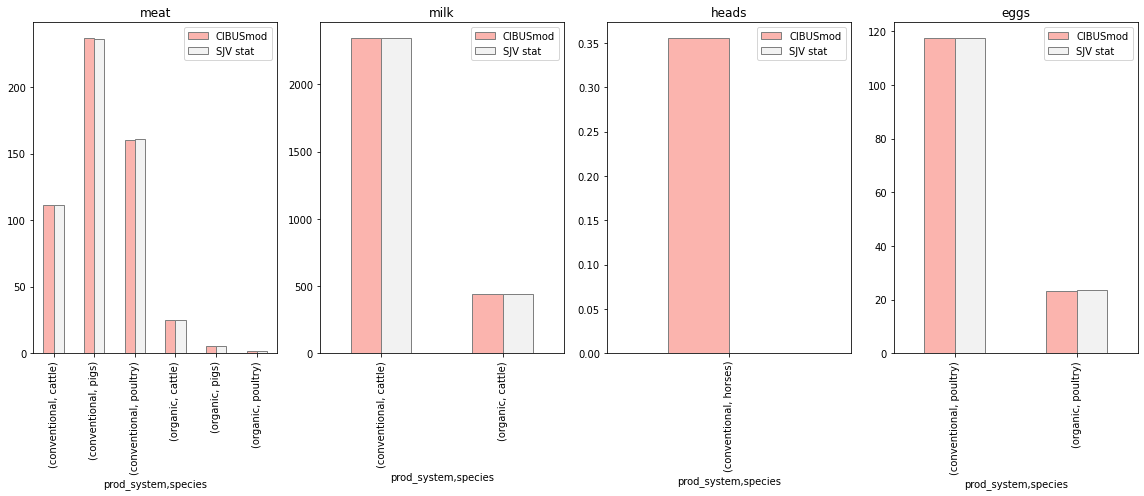

In [27]:
# SJV statistics 2016-2020
# 1000 tonnes
tot_milk = (2862.23+2816.66+2760.23+2704.39+2772.74)/5
org_milk = (369.20+414.23+464.97+464.17+481.20)/5

tot_cattle_meat = (131.25+132.07+136.87+139.67+141.00)/5
org_cattle_meat = (18887+19088+19290+21806+22382+21853)/5/1000

tot_pig_meat = (232.80+240.70+249.79+240.29+246.54)/5
org_pig_meat = (4819+4811+5540+6135+6553)/5/1000

tot_sheep_meat = (5.04+5.26+5.60+5.09+4.86)/5
org_sheep_meat = (1138+1109+1187+1063+993)/5/1000

tot_poultry_meat = (158.03+158.78+156.75+165.22+172.28)/5 # Summa fjäderfä, exkl kasserade
tot_poultry_meat2 = (148.49+148.54+146.28+155.18+162.06)/5 # Slaktkyckling, exkl kasserade
org_poultry_meat2 = (1523+1667+1217+1333+1420)/5/1000 # Slaktkyckling
org_poultry_meat = org_poultry_meat2 * tot_poultry_meat/tot_poultry_meat2

tot_eggs = (120.71*1.135 + 118.19*1.14 + 122.79*1.13 + 130.30*1.13 + 129.74*1.13)/5 
org_eggs = (21.35*1.135 + 20.38*1.14 + 20.54*1.13 + 20.46*1.13 + 20.45*1.13)/5

stat = pd.Series(
    {
        ('conventional','cattle','meat')    : tot_cattle_meat-org_cattle_meat,
        ('organic','cattle','meat')         : org_cattle_meat,
        ('conventional','cattle','milk')    : tot_milk-org_milk,
        ('organic','cattle','milk')         : org_milk,
        ('conventional','pigs','meat')      : tot_pig_meat-org_pig_meat,
        ('organic','pigs','meat')           : org_pig_meat,
        ('conventional','poultry','meat')   : tot_poultry_meat-org_poultry_meat,
        ('organic','poultry','meat')        : org_poultry_meat,
        ('conventional','poultry','eggs')   : tot_eggs-org_eggs,
        ('organic','poultry','eggs')        : org_eggs
    },
).sort_index().rename_axis(['prod_system','species','animal_prod'])

plot_data = pd.concat([
    output.get_attr('D','animal_prod_demand',['prod_system','species','animal_prod']).iloc[0].rename('CIBUSmod')/1000000,
    stat.rename('SJV stat')
], axis=1)

aps = plot_data.index.get_level_values('animal_prod').unique()
fig, axs = fig, axs = plt.subplots(1,len(aps), figsize=(16,7))

i=0
for ap in aps:
    ax = axs[i]
    plot_data.xs(ap,level='animal_prod').plot(**bar_style, ax=ax)
    ax.set_title(ap)
    i+=1
    
plt.tight_layout()
plt.show()

### Manure excretion

#### Volatile solids

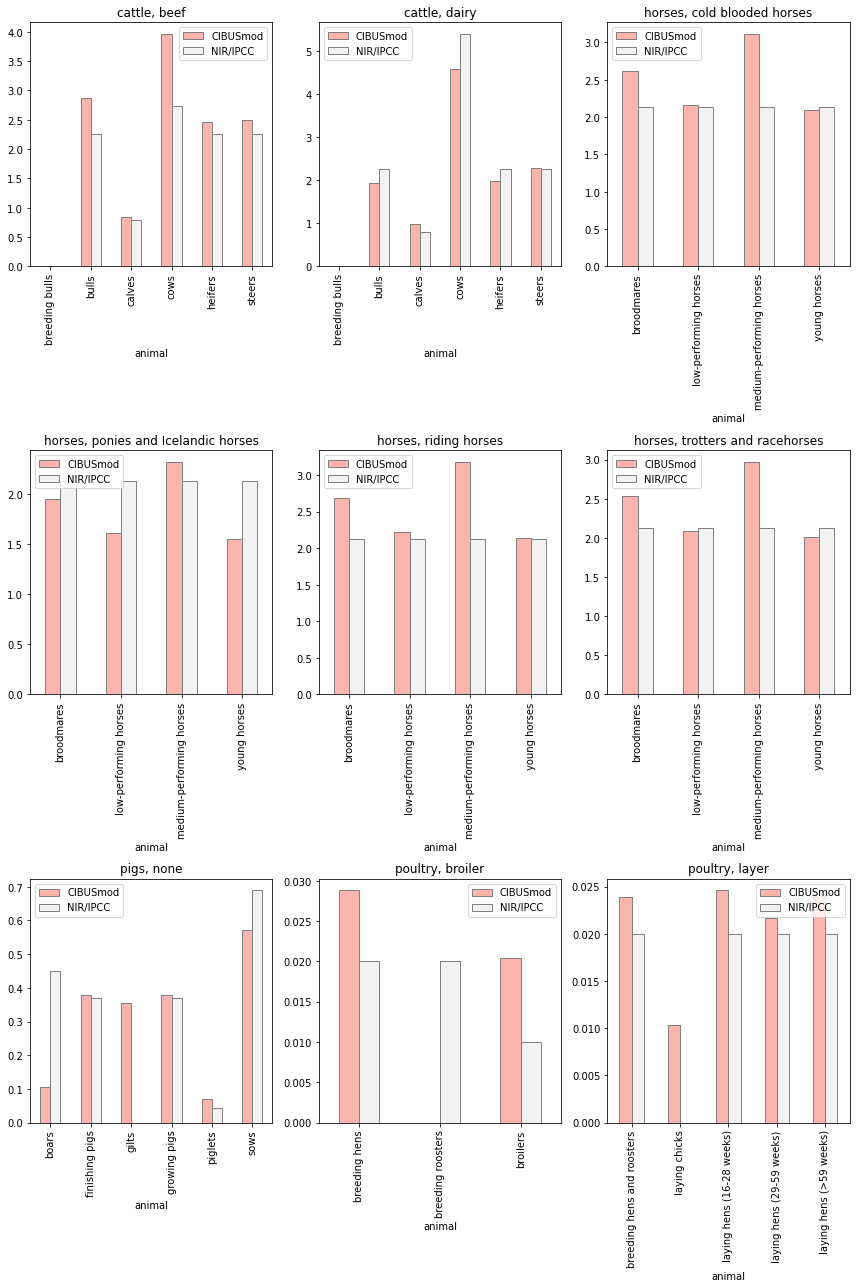

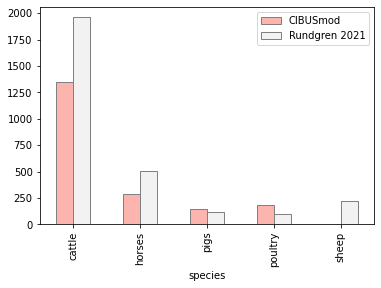

In [29]:
VS_per_head = (
    output.get_attr('A','manure.VS_excr',['species','breed','animal']) / 
    output.get_attr('A','heads',['species','breed','animal']) /
    365.25
).iloc[0].rename('CIBUSmod')

NIR_IPCC = pd.Series({
    ('cattle','dairy','cows'):5.39,
    ('cattle','dairy','calves'):0.79,
    ('cattle','dairy','heifers'):2.26,
    ('cattle','dairy','steers'):2.26,
    ('cattle','dairy','bulls'):2.26,
    ('cattle','beef','cows'):2.74, # Avg. grazing / stable
    ('cattle','beef','calves'):0.79,
    ('cattle','beef','heifers'):2.26,
    ('cattle','beef','steers'):2.26,
    ('cattle','beef','bulls'):2.26,
    ('horses','cold blooded horses','broodmares') : 2.13,
    ('horses','cold blooded horses','low-performing horses') : 2.13,
    ('horses','cold blooded horses','medium-performing horses') : 2.13,
    ('horses','cold blooded horses','young horses') : 2.13,
    ('horses','ponies and Icelandic horses','broodmares') : 2.13,
    ('horses','ponies and Icelandic horses','low-performing horses') : 2.13,
    ('horses','ponies and Icelandic horses','medium-performing horses') : 2.13,
    ('horses','ponies and Icelandic horses','young horses') : 2.13,
    ('horses','riding horses','broodmares') : 2.13,
    ('horses','riding horses','low-performing horses') : 2.13,
    ('horses','riding horses','medium-performing horses') : 2.13,
    ('horses','riding horses','young horses') : 2.13,
    ('horses','trotters and racehorses','broodmares') : 2.13,
    ('horses','trotters and racehorses','low-performing horses') : 2.13,
    ('horses','trotters and racehorses','medium-performing horses') : 2.13,
    ('horses','trotters and racehorses','young horses') : 2.13,
    ('pigs','none','boars') : 0.45,
    ('pigs','none','finishing pigs') : 0.37,
    ('pigs','none','gilts') : np.nan,
    ('pigs','none','growing pigs') : 0.37,
    ('pigs','none','piglets') : 0.044,
    ('pigs','none','sows') : 0.69,
    ('poultry','broiler','breeding hens') : 0.02,
    ('poultry','broiler','breeding roosters') : 0.02,
    ('poultry','broiler','broilers') : 0.01,
    ('poultry','layer','breeding hens and roosters') : 0.02,
    ('poultry','layer','laying chicks') : np.nan,
    ('poultry','layer','laying hens (16-28 weeks)') : 0.02,
    ('poultry','layer','laying hens (29-59 weeks)') : 0.02,
    ('poultry','layer','laying hens (>59 weeks)') : 0.02,
}).rename('NIR/IPCC')
NIR_IPCC.index.names = VS_per_head.index.names

plot_data = pd.concat([
    VS_per_head,
    NIR_IPCC
], axis=1)

fig,axs = plot.subplots(plot_data,['species','breed'],**bar_style,size=(4,6))
plt.tight_layout()
plt.show()

# Compared to Rundgren 2021
plot_data = pd.concat([
    output.get_attr('A','manure.VS_excr','species').iloc[0].rename('CIBUSmod')/1000000,
    pd.Series(
        [1960,510,217,119,60+39],
        index=pd.Index(['cattle','horses','sheep','pigs','poultry'], name='species'),
        name='Rundgren 2021'
    )
], axis=1)

plot_data.plot(**bar_style)
plt.show()

#### Nitrogen

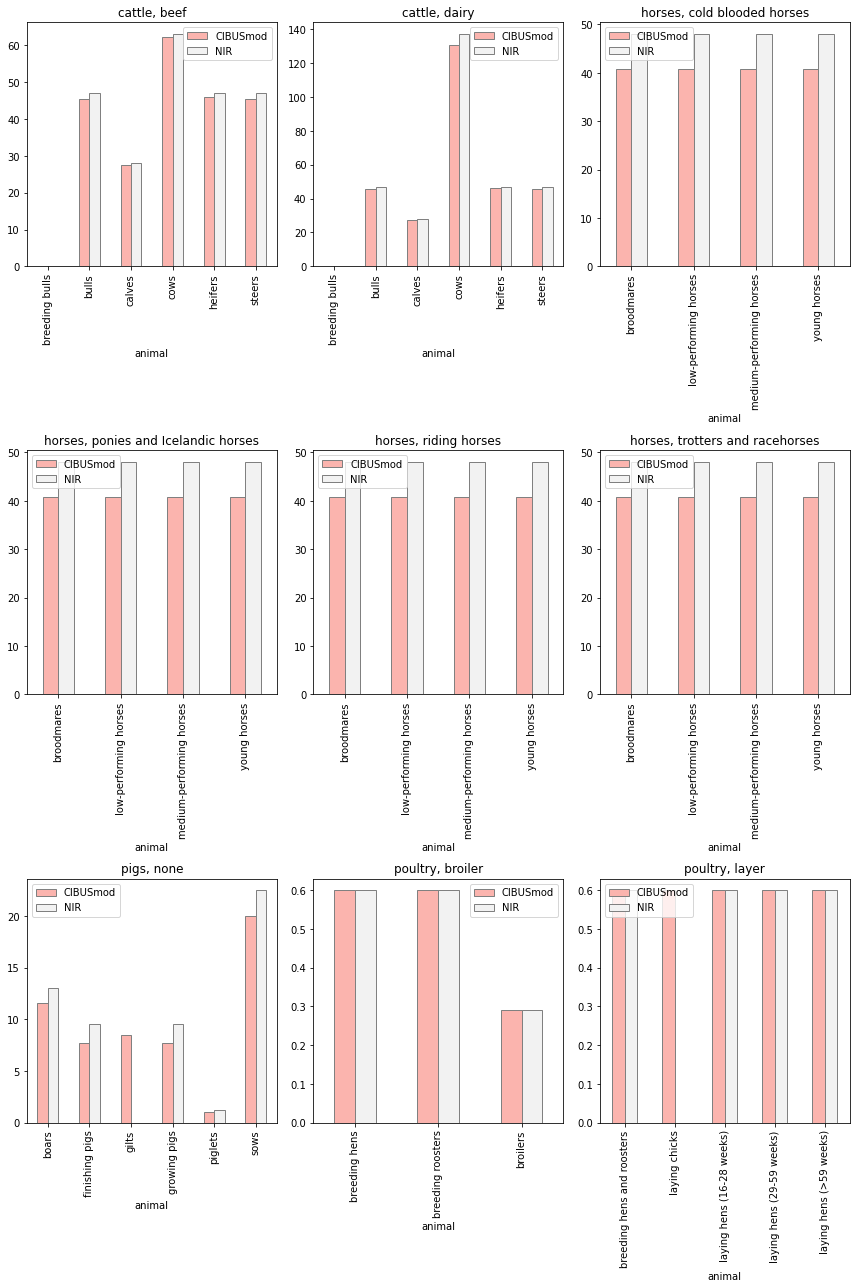

In [30]:
N_per_head = (
    output.get_attr('A','manure.N_excr',['species','breed','animal']) / 
    output.get_attr('A','heads',['species','breed','animal'])
).iloc[0].rename('CIBUSmod')

NIR = pd.Series({
    ('cattle','dairy','cows'):137,
    ('cattle','dairy','calves'):28,
    ('cattle','dairy','heifers'):47,
    ('cattle','dairy','steers'):47,
    ('cattle','dairy','bulls'):47,
    ('cattle','beef','cows'):63,
    ('cattle','beef','calves'):28,
    ('cattle','beef','heifers'):47,
    ('cattle','beef','steers'):47,
    ('cattle','beef','bulls'):47,
    ('horses','cold blooded horses','broodmares') : 48,
    ('horses','cold blooded horses','low-performing horses') : 48,
    ('horses','cold blooded horses','medium-performing horses') : 48,
    ('horses','cold blooded horses','young horses') : 48,
    ('horses','ponies and Icelandic horses','broodmares') : 48,
    ('horses','ponies and Icelandic horses','low-performing horses') : 48,
    ('horses','ponies and Icelandic horses','medium-performing horses') : 48,
    ('horses','ponies and Icelandic horses','young horses') : 48,
    ('horses','riding horses','broodmares') : 48,
    ('horses','riding horses','low-performing horses') : 48,
    ('horses','riding horses','medium-performing horses') : 48,
    ('horses','riding horses','young horses') : 48,
    ('horses','trotters and racehorses','broodmares') : 48,
    ('horses','trotters and racehorses','low-performing horses') : 48,
    ('horses','trotters and racehorses','medium-performing horses') : 48,
    ('horses','trotters and racehorses','young horses') : 48,
    ('pigs','none','boars') : 13,
    ('pigs','none','finishing pigs') : 9.5,
    ('pigs','none','gilts') : np.nan,
    ('pigs','none','growing pigs') : 9.5,
    ('pigs','none','piglets') : 1.2,
    ('pigs','none','sows') : 22.5,
    ('poultry','broiler','breeding hens') : 0.6,
    ('poultry','broiler','breeding roosters') : 0.6,
    ('poultry','broiler','broilers') : 0.29,
    ('poultry','layer','breeding hens and roosters') : 0.6,
    ('poultry','layer','laying chicks') : np.nan,
    ('poultry','layer','laying hens (16-28 weeks)') : 0.6,
    ('poultry','layer','laying hens (29-59 weeks)') : 0.6,
    ('poultry','layer','laying hens (>59 weeks)') : 0.6,
}).rename('NIR')
NIR.index.names = N_per_head.index.names

plot_data = pd.concat([
    N_per_head,
    NIR
], axis=1)

fig,axs = plot.subplots(plot_data,['species','breed'],**bar_style,size=(4,6))
plt.tight_layout()
plt.show()

### GHG emissions compared to NIR

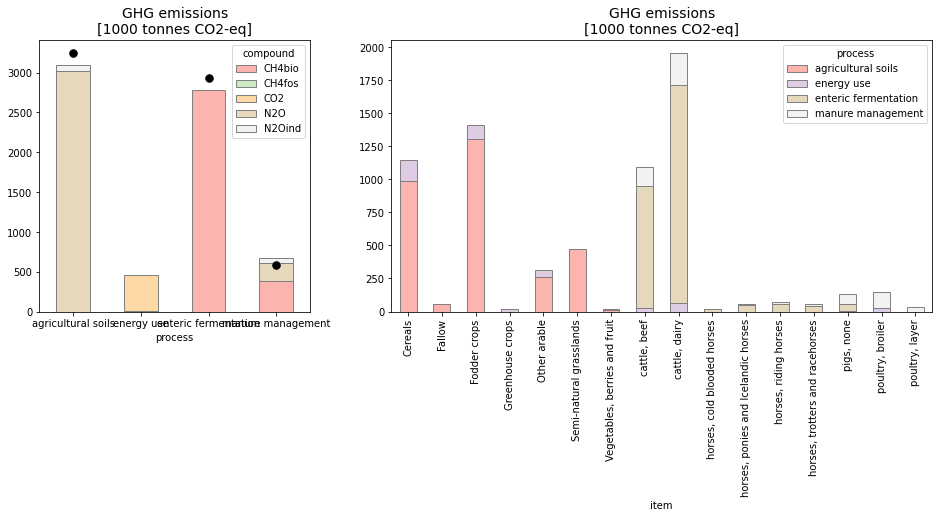

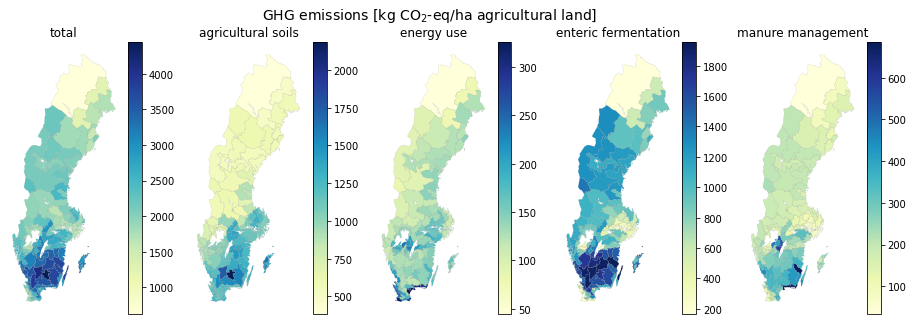

In [43]:
# Bar plot [1000 tonnes CO2eq] ----->
fig, axs = plt.subplots(1,2, figsize=(16,5), gridspec_kw={'width_ratios': [1, 2]})
plot_data = (
    get_GHG(output)
    .sum()
    .groupby(['process','compound'])
    .sum()
    .unstack()
    /1000000
)
plot_data_NIR = pd.Series(
    [3250,np.nan,2930,590],
    index=pd.Index(['agricultural soils','energy use','enteric fermentation','manure management'], name='process')
)
ax=axs[0]
plot_data.plot(**bar_style, stacked='True', ax=ax)
plot_data_NIR.plot(kind='line', ax=ax, linestyle='', marker='.', markersize=15, color='black')
ax.set_title('GHG emissions\n[1000 tonnes CO2-eq]', size=14)

plot_data = (
    get_GHG(output)
    .sum()
    .groupby(['item','process'])
    .sum()
    .unstack()
    /1000000
)
ax = axs[1]
plot_data.plot(**bar_style, stacked='True', ax=ax)
ax.set_title('GHG emissions\n[1000 tonnes CO2-eq]', size=14)

plt.show()

# Maps [kg CO2eq/ha] ----->
area = (
    output.get_attr('C','area',{'crop':'land_use','region':None})
    .iloc[0].drop('greenhouse')
    .groupby('region').sum()
)

plot_data = (
    get_GHG(output)
    .groupby('process', axis=1)
    .sum()
    .mul(1/area, axis=0)
)

fig, axs = plt.subplots(1,5, figsize=(16,5))
ax = axs[0]
plot.map_from_series(plot_data.sum(axis=1), **map_style, ax=ax)
ax.set_title('total')
ax.axis('off')
i = 1
for proc in plot_data.columns:
    ax = axs[i]
    plot.map_from_series(plot_data[proc], **map_style, ax=ax)
    ax.set_title(proc)
    ax.axis('off')
    i += 1
plt.suptitle(r'GHG emissions [kg CO$_{2}$-eq/ha agricultural land]', size=14)
plt.show()

### Nitrogen in manure and fertiliser

In [44]:
# Statisticts of nitrogen (total N) application on cropland for the years 2018/2019 and 2021/2022
# per total area of cropland in the region (i.e. includinga reas receiving no fertiliser) 
# [kg N/ha]

stat_N_per_ha = pd.DataFrame(
    {
        'manure' : [
            11.8,
            11.0,
            21.1,
            34.3,
            75.1,
            59.7,
            59.9,
            37.1,
            43.0,
            24.3,
            47.9,
            34.8,
            32.2,
            19.9,
            11.1,
            32.6,
            43.8,
            37.2,
            54.4,
            44.4,
            37.4
        ],
        'mineral' : [
            62.3,
            80.0,
            74.0,
            80.6,
            39.6,
            41.7,
            72.2,
            66.4,
            65.0,
            109.2,
            84.8,
            73.5,
            42.7,
            76.7,
            73.4,
            38.0,
            30.0,
            20.5,
            np.nan,
            31.7,
            32.0,
        ]
    },
    index = [
        '01 Stockholms län',
        '03 Uppsala län',
        '04 Södermanlands län',
        '05 Östergötlands län',
        '06 Jönköpings län',
        '07 Kronobergs län',
        '08 Kalmar län',
        '09 Gotlands län',
        '10 Blekinge län',
        '12 Skåne län',
        '13 Hallands län',
        '14 Västra Götalands län',
        '17 Värmlands län',
        '18 Örebro län',
        '19 Västmanlands län',
        '20 Dalarnas län',
        '21 Gävleborgs län',
        '22 Västernorrlands län',
        '23 Jämtlands län',
        '24 Västerbottens län',
        '25 Norrbottens län'
    ]
)
stat_N_per_ha['total'] = stat_N_per_ha.sum(axis=1)

# Total tot-N application [tonnes]
stat_N_total = pd.Series(
    [(180490+164320)/2, (77310+80510)/2],
    index = ['mineral','manure']
)

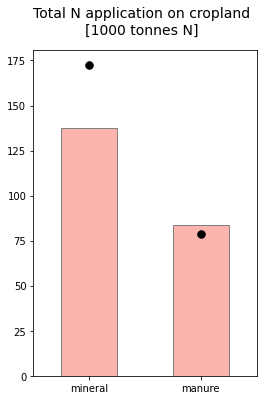

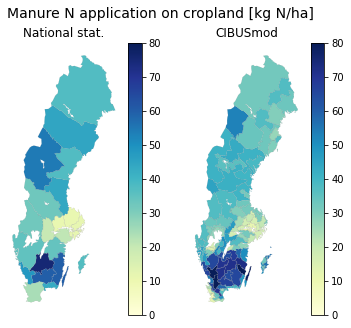

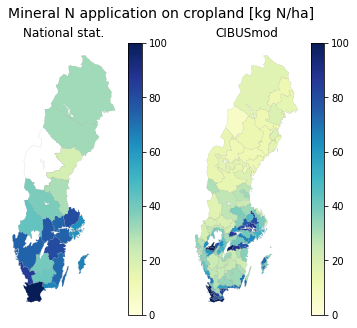

In [47]:
rel = cm.ParameterRetriever.get_rel('crop','land_use')
area = output.loc[(scn,year),'CropProduction'].area.to_frame()
area['lu'] = [rel[c] for c in area.index.get_level_values('crop')]
area = (
    area.loc[area['lu'].isin(['cropland']),0]
    .groupby('region')
    .sum()
)

# Total manure and mineral fertiliser [tonnes]
plot_data = pd.Series(
    [
        output.loc[(scn,year),'CropProduction']
        .fertiliser.mineral_N
        .rename(rel).loc['cropland']
        .sum().sum(),
        output.loc[(scn,year),'CropProduction']
        .fertiliser.manure_N
        .rename(rel).loc['cropland']
        .sum().sum()
    ],
    index = ['mineral','manure']
)/1000000
fig, ax = plt.subplots(figsize=(4,6))
plot_data.plot(**bar_style, ax = ax)
(stat_N_total/1000).plot(kind='line', ax=ax, linestyle='', marker='.', markersize=15, color='black')
plt.suptitle('Total N application on cropland\n[1000 tonnes N]', size=14)
plt.show()


# Manure per ha
fig, axs = plt.subplots(1,2, figsize=(6,5))
ax = axs[0]
ax.set_title('National stat.')
ax.axis('off')
plot.map_from_series(stat_N_per_ha['manure'], reg='län', **map_style, ax=ax, vmin=0, vmax=80)

ax = axs[1]
ax.set_title('CIBUSmod')
ax.axis('off')
plot_data = (
    output.loc[(scn,year),'CropProduction']
    .fertiliser.manure_N.sum(axis=1)
    .rename(rel).loc['cropland']
    .groupby('region').sum()
    / area
)
plot.map_from_series(plot_data, **map_style, ax=ax, vmin=0, vmax=80)
plt.suptitle('Manure N application on cropland [kg N/ha]', size=14)
plt.show()

# Mineral per ha
fig, axs = plt.subplots(1,2, figsize=(6,5))
ax = axs[0]
ax.set_title('National stat.')
ax.axis('off')
plot.map_from_series(stat_N_per_ha['mineral'], reg='län', **map_style, ax=ax, vmin=0, vmax=100)

ax = axs[1]
ax.set_title('CIBUSmod')
ax.axis('off')
plot_data = (
    output.loc[(scn,year),'CropProduction']
    .fertiliser.mineral_N.sum(axis=1)
    .rename(rel).loc['cropland']
    .groupby('region').sum()
    / area
)
plot.map_from_series(plot_data, **map_style, ax=ax, vmin=0, vmax=100)
plt.suptitle('Mineral N application on cropland [kg N/ha]', size=14)
plt.show()

### Energy use

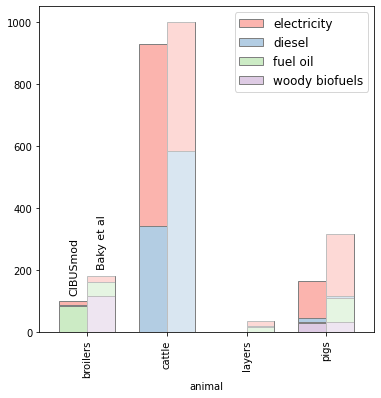

In [48]:
plot_data = (
    output.loc[(scn,year),'AnimalHerd']
    .energy_use.sum()
    .drop('horses', level='species')
    .rename({'beef':'all','dairy':'all'})
    .groupby(['species','breed','energy_source'])
    .sum()
    .unstack()
    .loc[:,['electricity','diesel','fuel oil','woody biofuels']]
    /1000000
)
plot_data.index = pd.MultiIndex.from_tuples(
    [('cattle','CIBUSmod'),('pigs','CIBUSmod'),
     ('broilers','CIBUSmod'),('layers','CIBUSmod')],
    names=['animal','data source']
)

plot_data.loc[('cattle','Baky et al'),:] =   [  341+76,   118+466,      0,       0 ]
plot_data.loc[('pigs','Baky et al'),:] =     [  134+66,       5+0,   79+0,    32+0 ]
plot_data.loc[('broilers','Baky et al'),:] = [      20,       0.6,     46,     116 ]
plot_data.loc[('layers','Baky et al'),:] =   [      19,       0.2,     19,       0 ]

fig, ax = plt.subplots(figsize=(6,6))
plot.bar_stacked_grouped(plot_data, ax=ax, cmap='Pastel1')
ax.legend(loc='upper right', bbox_to_anchor=(1, 1), fontsize=12)
plt.show()

plot_data.sort_index().style \
.format(precision=0, thousands=" ")

### By-products

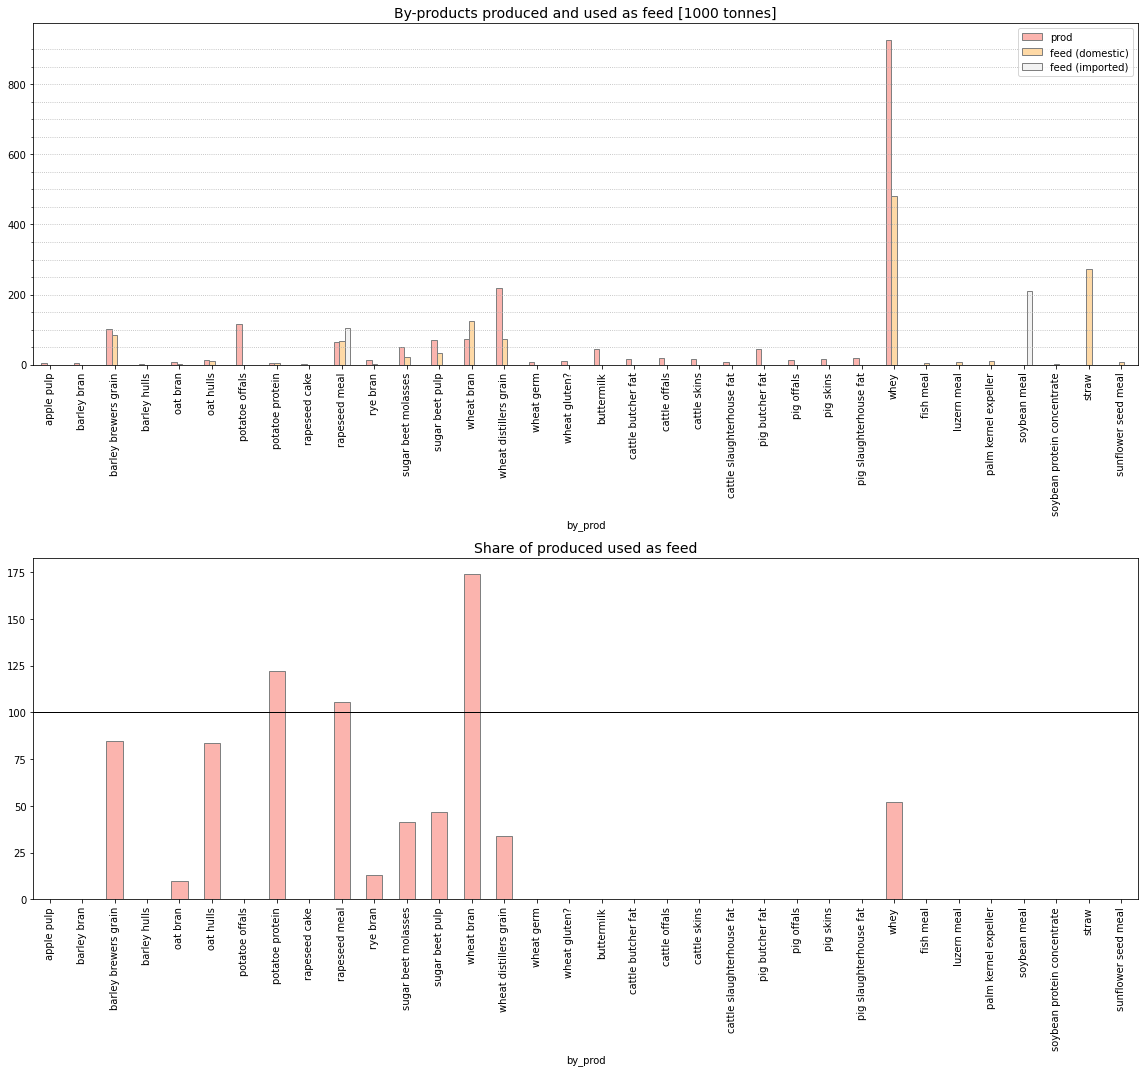

In [49]:
plot_data = pd.concat([
    pd.concat([
        
        output.loc[(scn,year),'DemandAndConversions'].crop_by_products.sum(axis=1)
        .groupby('by_prod').sum()
        .rename('prod'),
        
        output.loc[(scn,year),'DemandAndConversions'].animal_by_products.sum(axis=1)
        .groupby('by_prod').sum()
        .rename('prod')
        
    ]),
    
    output.loc[(scn,year),'AnimalHerd'].feed.by_product_demand.sum()
    .drop(index='regional',level='origin')
    .groupby(['by_prod','origin']).sum()
    .unstack()
    .rename({'domestic':'feed (domestic)','imported':'feed (imported)'}, axis=1)
    
], axis=1)/1000000
plot_data['% domestic used'] = plot_data['feed (domestic)']/plot_data['prod']*100

fig, axs = plt.subplots(2,1, figsize=(16,15))

ax=axs[0]
plot_data.loc[:,['prod','feed (domestic)','feed (imported)']].plot(**bar_style, ax=ax)

ax.set_title('By-products produced and used as feed [1000 tonnes]', size=14)
ax.set_yticks(range(0,int(plot_data.max().max()),50), minor=True)
ax.grid('on', linestyle=':', which='both', axis='y')

ax=axs[1]
plot_data.loc[:,'% domestic used'].plot(**bar_style, ax=ax)
ax.axhline(y=100, c='black', lw=1)
ax.set_title('Share of produced used as feed', size=14)

plt.tight_layout()
plt.show()

In [50]:
print('Unit: 1000 tonnes')
plot_data.style \
.format(precision=1, thousands=" ", decimal=".")

Unit: 1000 tonnes


,prod,feed (domestic),feed (imported),% domestic used
by_prod,,,,
apple pulp,5.5,nan,nan,nan
barley bran,3.7,nan,nan,nan
barley brewers grain,101.2,85.5,0.0,84.5
barley hulls,2.3,nan,nan,nan
oat bran,8.1,0.8,0.0,10.0
oat hulls,14.0,11.7,0.0,83.7
potatoe offals,117.0,nan,nan,nan
potatoe protein,4.2,5.1,0.0,122.3
rapeseed cake,0.7,nan,nan,nan


In [51]:
table_data = (
    output.loc[(scn,year),'AnimalHerd'].feed.by_product_demand.sum()
    .drop(index='regional',level='origin')
    .groupby(['by_prod','species','origin']).sum()
    .unstack()
    .unstack()
    .rename({'domestic':'feed (domestic)','imported':'feed (imported)'}, axis=1)
    .fillna(0)
    /1000
)
table_data[('total','')] = table_data.sum(axis=1)
table_data.loc['total',:] = table_data.sum()

print('Unit: tonnes')
table_data.style \
.format(precision=0, thousands=" ", decimal=".",)

Unit: tonnes


In [52]:
table_data = (
    output.loc[(scn,year),'AnimalHerd']
    .feed.consumption.sum()
    .xs('cattle')
    .groupby(['breed','animal','feed']).sum()
    .unstack(['breed','animal'])
    /
    output.loc[(scn,year),'AnimalHerd']
    .heads.sum()
    .xs('cattle')
    .groupby(['breed','animal']).sum()
)

print('Unit: kg DM/head')
table_data.style \
.format(precision=1, thousands=" ", decimal=".",)

Unit: kg DM/head


In [53]:
table_data = (
    output.loc[(scn,year),'AnimalHerd']
    .feed.consumption.sum()
    .groupby(['species','feed']).sum()
    .unstack(['species'])
).fillna(0)/1000
table_data['total'] = table_data.sum(axis=1)
table_data.loc['total',:] = table_data.sum()

print('Unit: tonnes DM')
table_data.style \
.format(precision=0, thousands=" ", decimal=".",)

Unit: tonnes DM


species,cattle,horses,pigs,poultry,total
feed,,,,,
barley,349 067,1 000,223 244,11 263,584 574
barley brewers grain,0,0,20 958,0,20 958
broad beans,14 898,0,46 463,0,61 361
fish meal,0,0,3 096,0,3 096
grazing,1 037 827,281 605,0,0,1 319 432
hay,0,738 115,0,0,738 115
"ley silage, 1st cut",1 419 723,0,0,0,1 419 723
"ley silage, regrowth",887 793,0,0,0,887 793
linseed,62,0,202,0,264


### Crop areas (deviation from x0)

#### Total crop areas

In [56]:
output.info()

*-----------------*
| CIBUSmod Output |
*-----------------*

Scenarios
---------
base year: 2020 

DemandAndConversions
--------------------
Data attributes:
animal_prod_demand, non_food_demand, export_demand, food_demand, crop_by_products, waste, animal_by_products, food_demand_to_processing, crop_prod_demand, population


Regions
-------
Data attributes:
soil, climate, x0_animals, x0_crops, max_land_use


CropProduction
--------------
Data attributes:
fertiliser.mineral_N, fertiliser.manure_N_soil_loss, production_per_use, fertiliser.manure_C, fertiliser.mineral_N_application_loss, production, fertiliser.organic_soil_N_loss, fertiliser.mineral_N_soil_loss, harvest, fertiliser.crop_residues_N, harvest_dm, crop_residues, seed_demand, fertiliser.TAN_req, fertiliser.crop_residues_N_soil_loss, fertiliser.manure_N_application_loss, energy_use_emissions, fertiliser.manure_N, fertiliser.manure_TAN, energy_use, area, harvested_crop_residues


AnimalHerd
----------
Data attributes:
lwg, feed.d

In [107]:
output.get_attr('R','x0_crops','crop').iloc[0].rename('x0')

crop
Apples                                   1552.000000
Barley, spring                         296954.736025
Barley, winter                          18442.502448
Beans, dry                                703.294000
Broad beans and horse beans, dry        25063.798921
Cabbages, cauliflowers and broccoli      1468.500000
Carrots                                  1760.500000
Cereals for fodder                      47620.434835
Cucumbers                                 134.000000
Cucumbers, greenhouse                  676923.499945
Currants                                  275.500000
Energy grass                              304.514000
Fallow                                 152605.312001
Green manure                             3439.164000
Herbs                                     209.500000
Herbs, greenhouse                      102441.000004
Lettuce and spinach                      1885.500000
Lettuce, greenhouse                     76813.499995
Ley for fodder                         76

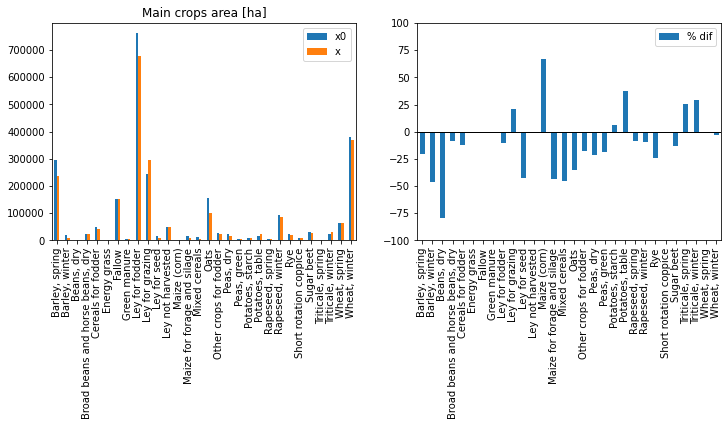

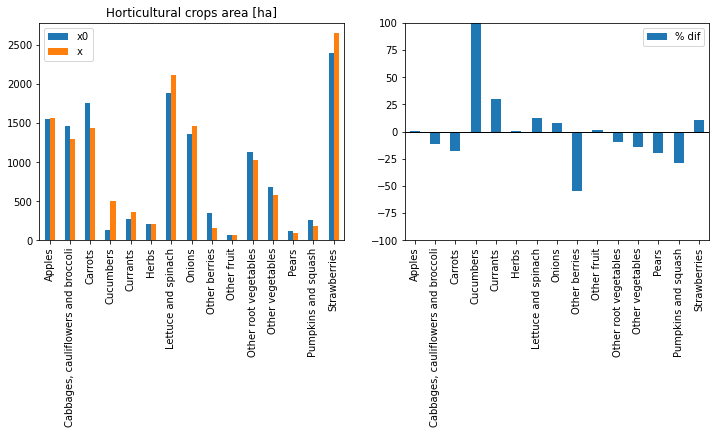

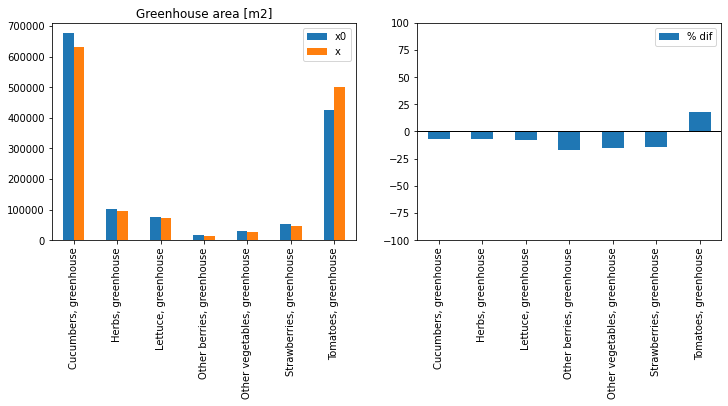

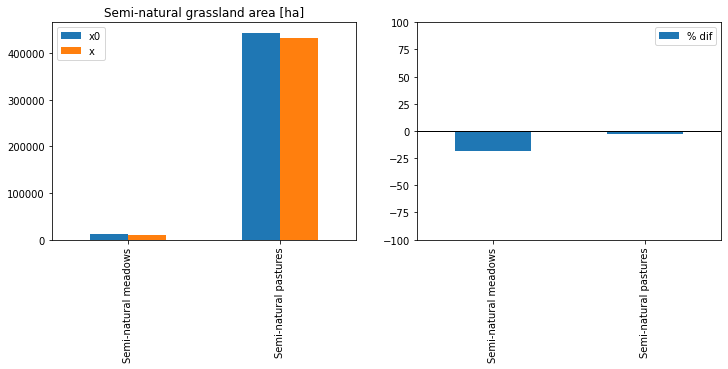

In [132]:
plot_data = pd.concat([
    output.get_attr('C','area',['crop']).iloc[0].rename('x'),
    output.get_attr('R','x0_crops',['crop']).iloc[0].rename('x0')
], axis=1)
plot_data['% dif'] = plot_data.apply(lambda x:(x['x']-x['x0'])/x['x0']*100, axis=1)

cg_dict = cm.ParameterRetriever.get_rel('crop','crop_group2')
plot_data['cg'] = [cg_dict[c] for c in plot_data.index.get_level_values(0)]

hr = ['Vegetables, berries and fruit']
gh = ['Greenhouse crops']
sng = ['Semi-natural grasslands']
cr = list(set(cg_dict.values()) - set(hr) - set(gh) - set(sng))

plots = {
    'Main crops area [ha]' : cr,
    'Horticultural crops area [ha]' : hr,
    'Greenhouse area [m2]' : gh,
    'Semi-natural grassland area [ha]' : sng
}

for p in plots:
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    
    ax=axs[0]
    plot_data[plot_data['cg'].isin(plots[p])].plot.bar(y=['x0','x'], ax=ax)
    ax.set_xlabel('')
    ax.set_title(p)
    
    ax=axs[1]
    plot_data[plot_data['cg'].isin(plots[p])].plot.bar(y='% dif', ax=ax)
    plt.axhline(y=0, c='black', lw=1)
    ax.set_xlabel('')
    ax.set_ylim(-100,100)
    
    plt.show()

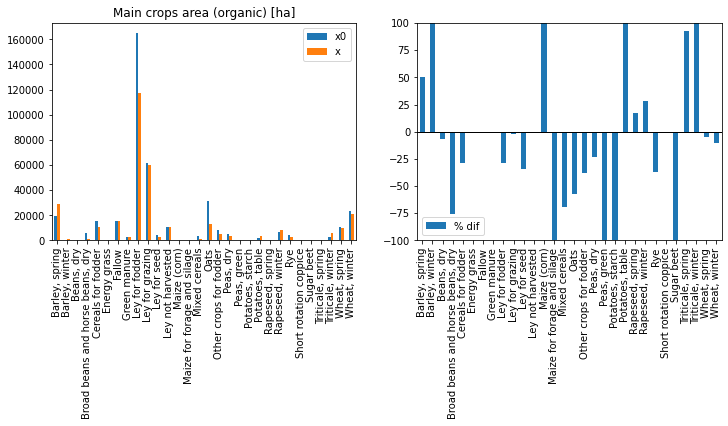

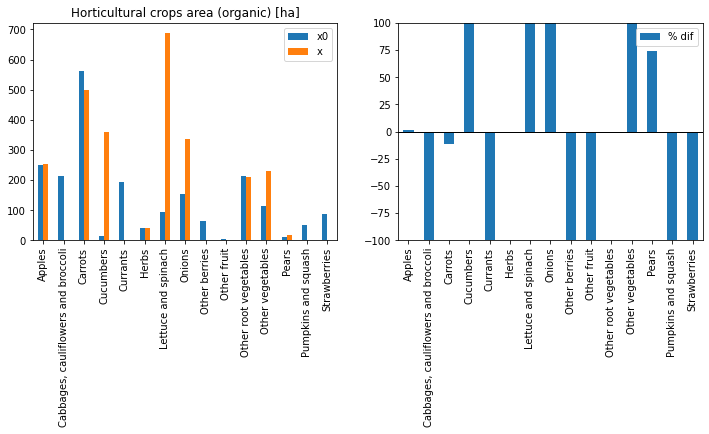

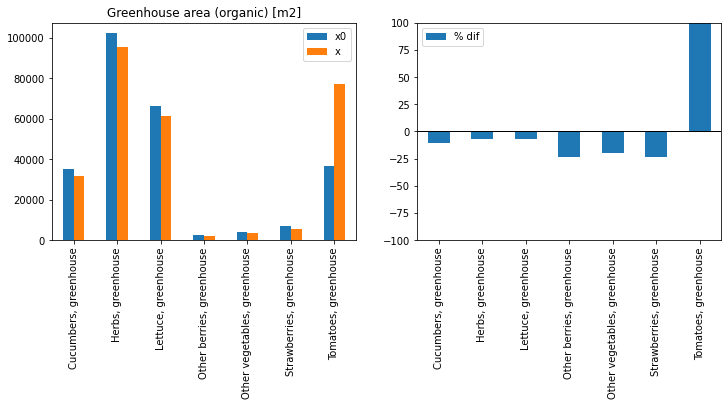

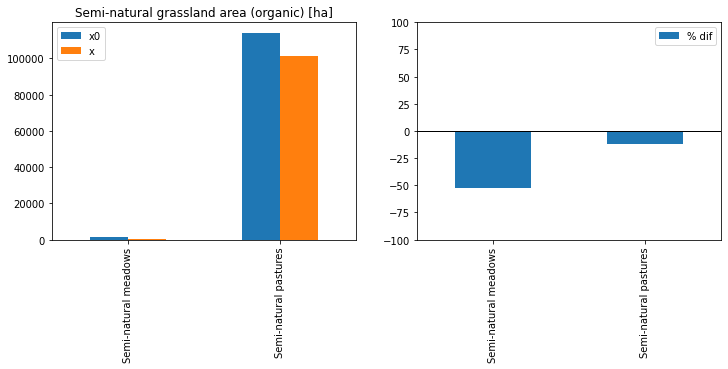

In [133]:
plot_data = pd.concat([
    output.get_attr('C','area',['crop','prod_system']).iloc[0].rename('x'),
    output.get_attr('R','x0_crops',['crop','prod_system']).iloc[0].rename('x0')
], axis=1)
plot_data['% dif'] = plot_data.apply(lambda x:(x['x']-x['x0'])/x['x0']*100 if x['x0']>0 else np.nan, axis=1)

cg_dict = cm.ParameterRetriever.get_rel('crop','crop_group2')
plot_data['cg'] = [cg_dict[c] for c in plot_data.index.get_level_values(0)]

hr = ['Vegetables, berries and fruit']
gh = ['Greenhouse crops']
sng = ['Semi-natural grasslands']
cr = list(set(cg_dict.values()) - set(hr) - set(gh) - set(sng))

plots = {
    'Main crops area (organic) [ha]' : cr,
    'Horticultural crops area (organic) [ha]' : hr,
    'Greenhouse area (organic) [m2]' : gh,
    'Semi-natural grassland area (organic) [ha]' : sng
}

plot_data = plot_data.xs('organic', level='prod_system')
for p in plots:
    fig, axs = plt.subplots(1,2, figsize=(12,4))
    
    ax=axs[0]
    plot_data[plot_data['cg'].isin(plots[p])].plot.bar(y=['x0','x'], ax=ax)
    ax.set_xlabel('')
    ax.set_title(p)
    
    ax=axs[1]
    plot_data[plot_data['cg'].isin(plots[p])].plot.bar(y='% dif', ax=ax)
    plt.axhline(y=0, c='black', lw=1)
    ax.set_xlabel('')
    ax.set_ylim(-100,100)
    
    plt.show()

#### Crop categories and some main crops per region

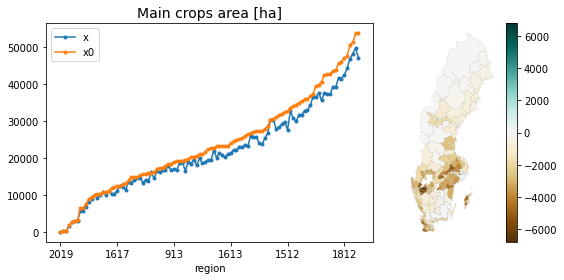

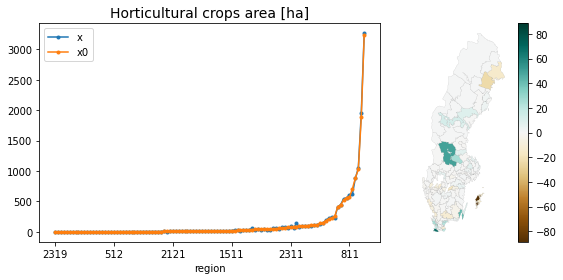

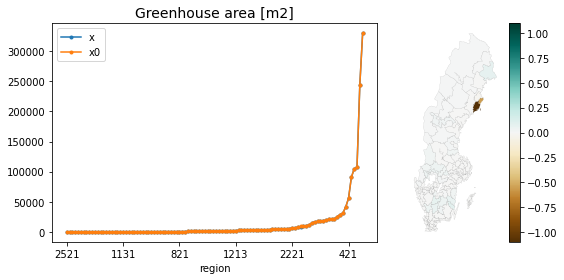

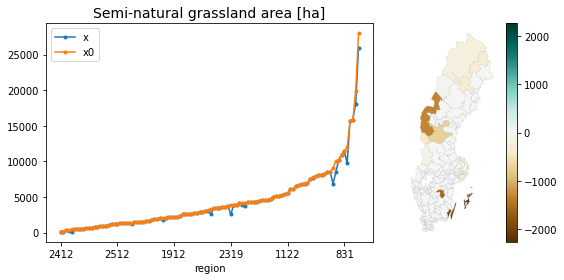

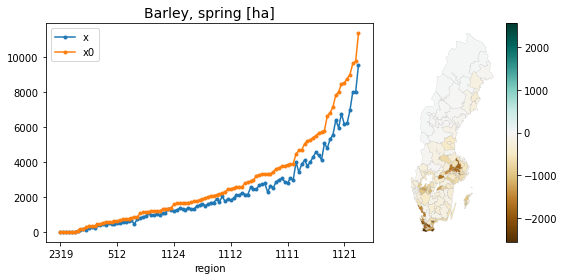

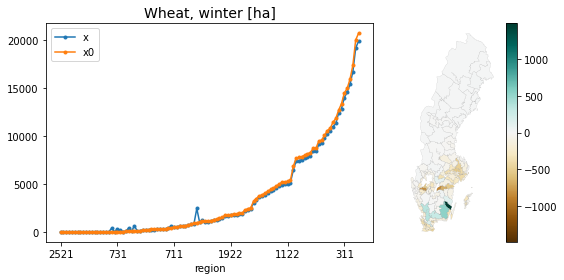

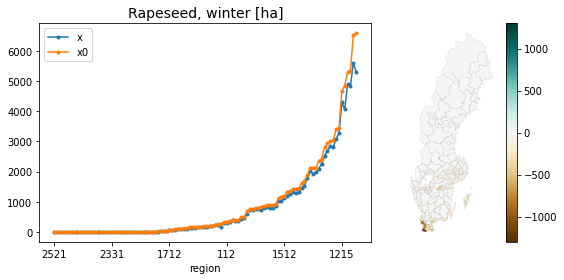

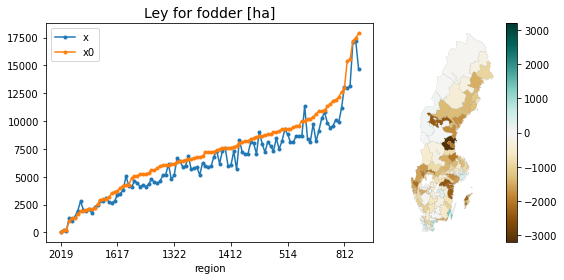

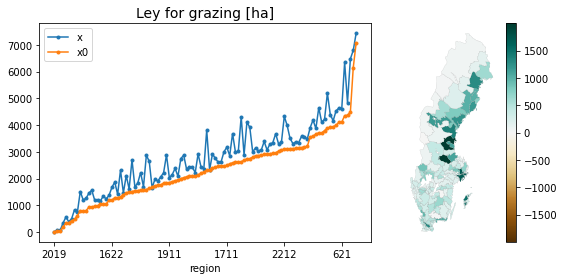

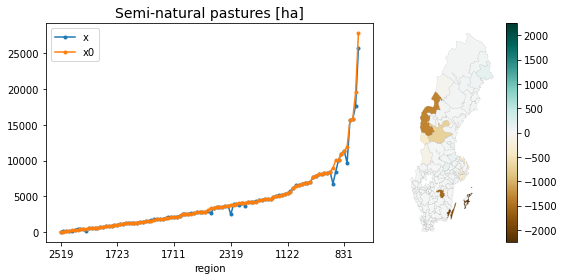

In [69]:
plot_data_ = (pd.concat([
    output.loc[(scn,year),'CropProduction'].area.groupby(['crop','region']).sum().rename('x'),
    output.loc[(scn,year),'Regions'].x0_crops.groupby(['crop','region']).sum().rename('x0')
], axis=1)
)

cg_dict = cm.ParameterRetriever.get_rel('crop','crop_group2')
plot_data_['cg'] = [cg_dict[c] for c in plot_data_.index.get_level_values('crop')]

hr = ['Vegetables, berries and fruit']
gh = ['Greenhouse crops']
sng = ['Semi-natural grasslands']
cr = list(set(cg_dict.values()) - set(hr) - set(gh) - set(sng))

plots = {
    'Main crops area [ha]' : cr,
    'Horticultural crops area [ha]' : hr,
    'Greenhouse area [m2]' : gh,
    'Semi-natural grassland area [ha]' : sng
}

for p in plots:

    # Crops
    plot_data = plot_data_.loc[plot_data_['cg'].isin(plots[p])].groupby('region').sum()
    plot_data['dif'] = (plot_data['x']-plot_data['x0'])
    plot_data.sort_values(by='x0', inplace=True)

    fig, axs = plt.subplots(1,2, figsize=(8,4), gridspec_kw={'width_ratios': [2, 1]})
    ax=axs[0]
    plot_data.plot(kind='line', marker='.', y=['x','x0'], ax=ax)
    ax.set_title(p, size=14)

    ax=axs[1]
    lim = max(abs(plot_data['dif']))
    plot.map_from_series(
        plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
        ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
    )
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

# Some main crops
crps = ['Barley, spring','Wheat, winter','Rapeseed, winter','Ley for fodder','Ley for grazing','Semi-natural pastures']
for crp in crps:
    plot_data = plot_data_.loc[crp].groupby('region').sum()
    plot_data['dif'] = (plot_data['x']-plot_data['x0'])
    plot_data.sort_values(by='x0', inplace=True)

    fig, axs = plt.subplots(1,2, figsize=(8,4), gridspec_kw={'width_ratios': [2, 1]})
    ax=axs[0]
    plot_data.plot(kind='line', marker='.', y=['x','x0'], ax=ax)
    ax.set_title(crp+' [ha]', size=14)

    ax=axs[1]
    lim = max(abs(plot_data['dif']))
    plot.map_from_series(
        plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
        ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
    )
    ax.axis('off')

    plt.tight_layout()
    plt.show()

### Animal numbers (deviations from x0)

#### Total animal numbers

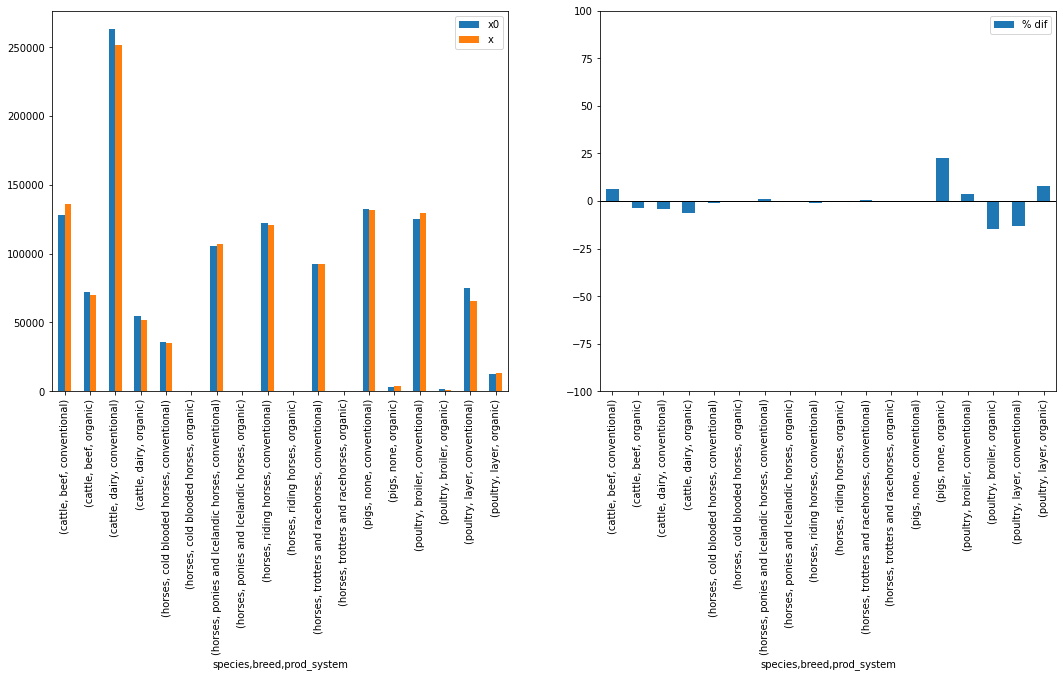

In [91]:
idx = pd.IndexSlice

plot_data_ = (
    pd.concat([
        output.loc[(scn,year),'AnimalHerd'].heads
        .loc[:,idx[:,:,:,:,[
            'cows',
            'sows','gilts',
            'broodmares','low-performing horses','medium-performing horses','young horses',
            'broilers',
            'laying hens (16-28 weeks)','laying hens (29-59 weeks)','laying hens (>59 weeks)','breeding hens and roosters'
        ]]]
        .groupby(['species','breed','prod_system'], axis=1).sum()
        .stack([0,1,2])
        .rename('x')
        ,
        output.loc[(scn,year),'Regions'].x0_animals
        .groupby(['region','species','breed','prod_system']).sum()
        .rename('x0')
    ], axis=1)
)
plot_data_
# Adjust poultry to 100 heads
plot_data_ = \
plot_data_.mul(np.where(plot_data_.index.get_level_values('species')=='poultry',1/100,1), axis=0)

plot_data = plot_data_.groupby(['species','breed','prod_system']).sum()
plot_data['% dif'] = (plot_data['x']-plot_data['x0'])/plot_data['x0']*100

fig, axs = plt.subplots(1,2, figsize=(18,7))
plot_data.plot.bar(y=['x0','x'], ax=axs[0])
plot_data.plot.bar(y='% dif', ax=axs[1])
plt.axhline(y=0, c='black', lw=1)
axs[1].set_ylim(-100,100)
plt.show()

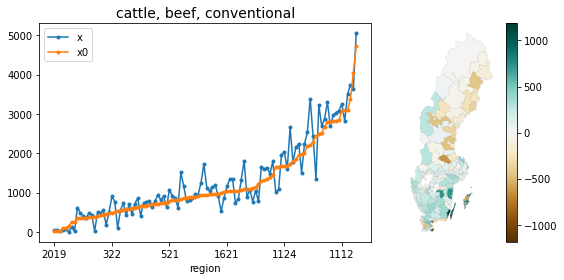

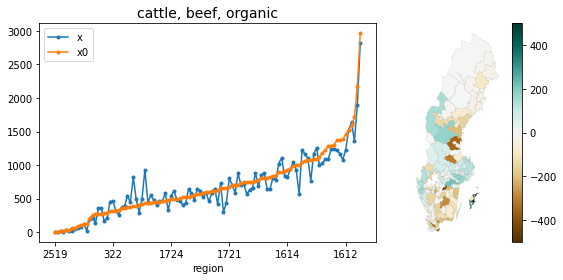

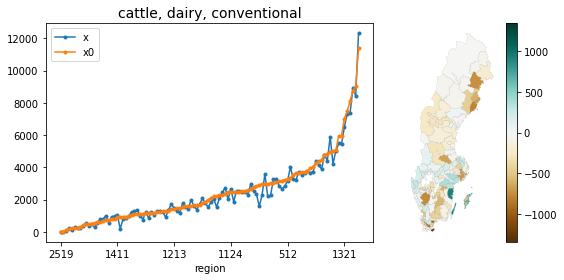

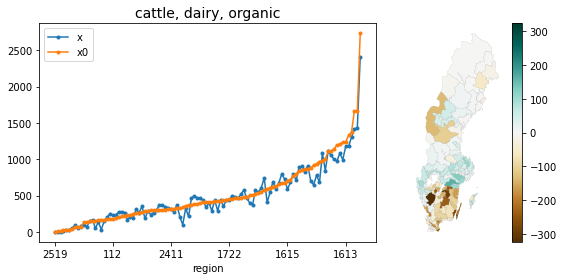

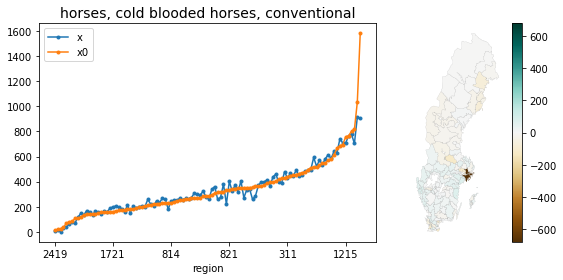

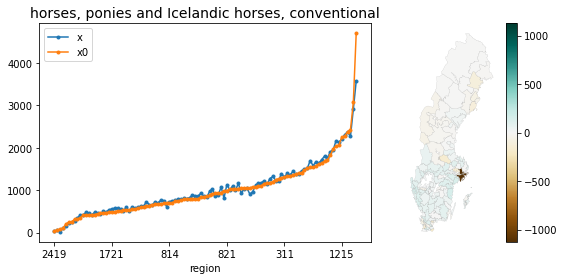

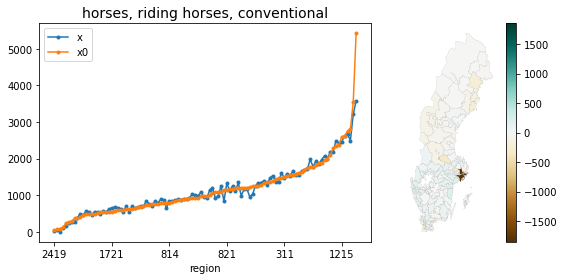

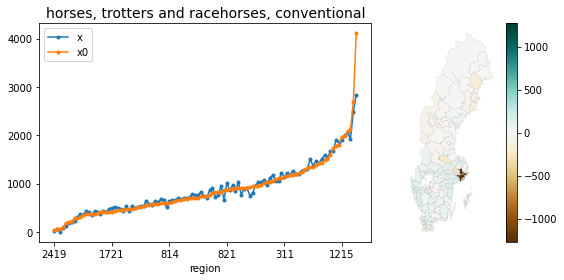

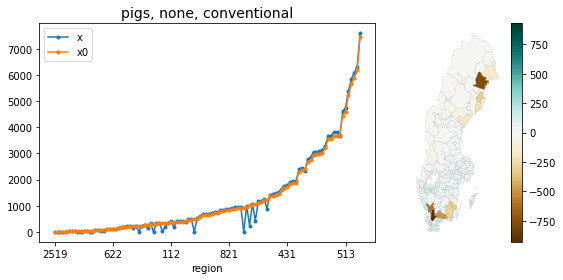

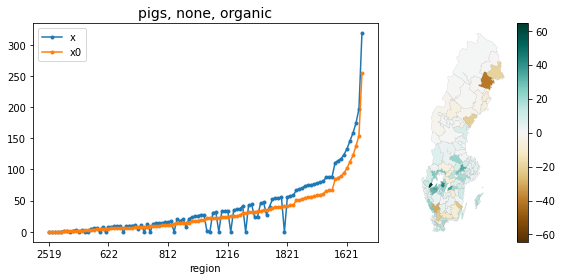

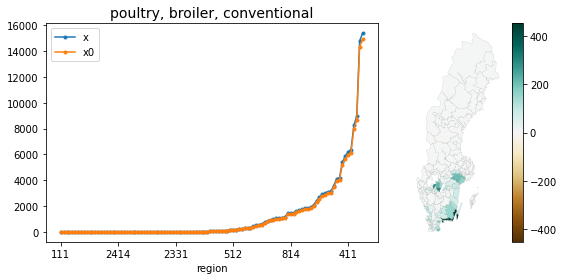

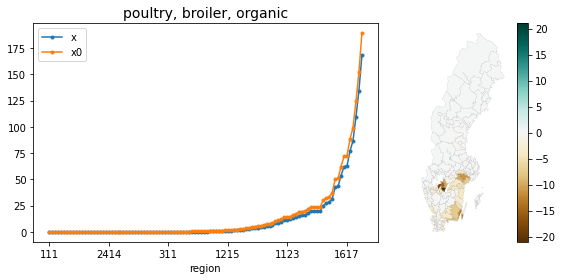

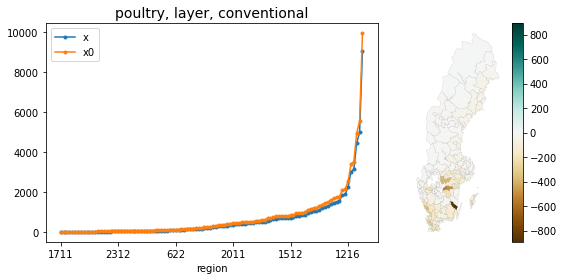

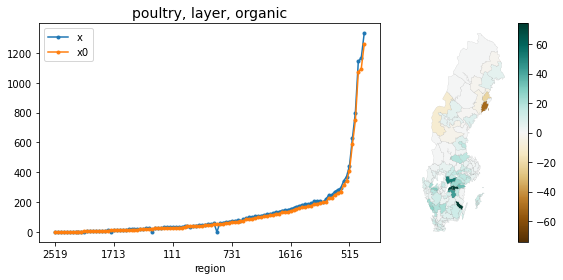

In [105]:
for idx in plot_data_.index.droplevel('region').unique():
    
    if 'horses' in idx and 'organic' in idx:
        continue
        
    plot_data = plot_data_.xs(idx, level=('species','breed','prod_system')).copy()
    plot_data['dif'] = (plot_data['x']-plot_data['x0'])
    plot_data.sort_values(by='x0', inplace=True)

    fig, axs = plt.subplots(1,2, figsize=(8,4), gridspec_kw={'width_ratios': [2, 1]})
    ax=axs[0]
    plot_data.plot(kind='line', marker='.', y=['x','x0'], ax=ax)
    ax.set_title(', '.join(idx), size=14)

    ax=axs[1]
    lim = max(abs(plot_data['dif']))
    plot.map_from_series(
        plot_data['dif'].replace({np.inf:0, -np.inf:0}).fillna(0),
        ax=ax, vmin=-lim, vmax=lim, cmap='BrBG', edgecolor='grey'
    )
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()

### Data to ICBM

In [67]:
icbm = cm.to_ICBM(
    pd.concat([
        output,
        output.rename({'2020':'2050'})
    ])
)
icbm

par                                                 area_ha   harvest_kgdm  \
scn       crop          prod_system  region year                             
base year Apples        conventional 1011   2020  24.771165   42638.191233   
                                            2021  24.771165   42638.191233   
                                            2022  24.771165   42638.191233   
                                            2023  24.771165   42638.191233   
                                            2024  24.771165   42638.191233   
...                                                     ...            ...   
          Wheat, winter organic      913    2046  71.918038  232922.180932   
                                            2047  71.918038  232922.180932   
                                            2048  71.918038  232922.180932   
                                            2049  71.918038  232922.180932   
                                            2050  71.918038  232922.180932   

par                                               manure_cattle_kgC  \
scn       crop          prod_system  region year                      
base year Apples        conventional 1011   2020        4493.827234   
                                            2021        4493.827234   
                                            2022        4493.827234   
                                            2023        4493.827234   
                                            2024        4493.827234   
...                                                             ...   
          Wheat, winter organic      913    2046       97030.191575   
                                            2047       97030.191575   
                                            2048       97030.191575   
                                            2049       97030.191575   
                                            2050       97030.191575   

par                                               manure_horses_kgC  \
scn       crop          prod_system  region year                      
base year Apples        conventional 1011   2020         953.648233   
                                            2021         953.648233   
                                            2022         953.648233   
                                            2023         953.648233   
                                            2024         953.648233   
...                                                             ...   
          Wheat, winter organic      913    2046        3040.463391   
                                            2047        3040.463391   
                                            2048        3040.463391   
                                            2049        3040.463391   
                                            2050        3040.463391   

par                                               manure_pigs_kgC  \
scn       crop          prod_system  region year                    
base year Apples        conventional 1011   2020      1101.499217   
                                            2021      1101.499217   
                                            2022      1101.499217   
                                            2023      1101.499217   
                                            2024      1101.499217   
...                                                           ...   
          Wheat, winter organic      913    2046      6299.117438   
                                            2047      6299.117438   
                                            2048      6299.117438   
                                            2049      6299.117438   
                                            2050      6299.117438   

par                                               manure_poultry_kgC  
scn       crop          prod_system  region year                      
base year Apples        conventional 1011   2020          884.436496  
                          

In [ ]:
icbm.to_csv('data_to_ICBM.csv')